In [53]:
# Libraries for files and images
import os
import cv2
# Numerical operations
import numpy as np
# Deep learning
import torch
from torchvision import models
import torchvision.transforms as T
# Image handling
from PIL import Image
# Similarity calculation
from numpy import dot
from numpy.linalg import norm
# Visualisation
import matplotlib.pyplot as plt
# Dataset splitting
from sklearn.model_selection import train_test_split
import random
import pandas as pd

In [54]:
# Dataset folders
DATASET_PATHS = ["Cattely-Augmented", "cow","dataset_df"]
# Allowed image types
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")
# Number of matches to return
TOP_K = 3
# Threshold for recognising a cow
THRESHOLD = 0.8

In [55]:
# Use GPU if available, otherwise CPU
device = "cuda" if torch .cuda.is_available() else "cpu"
print("Using device: "+ device)

Using device: cpu


In [56]:
def build_feature_extractor():
    # Load pretrained ResNet50
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    # Remove final layer to just get features
    model = torch.nn.Sequential(*list(model.children())[:-1])
    # Move to device and set to eval mode
    model.to(device)
    model.eval()
    return model
# Create model
feature_extractor = build_feature_extractor()

In [57]:
# Image preprocessing for ResNet50
preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [58]:
def load_cow_images(dataset_path):
    cows = {}
    
    # Check path exists
    if not os.path.exists(dataset_path):
        print(f"Warning: {dataset_path} not found")
        return cows
    # Loop through folders
    for cow_id in sorted(os.listdir(dataset_path)):
        cow_dir = os.path.join(dataset_path, cow_id)

        if os.path.isdir(cow_dir):
            # Get all valid image files
            images = [
                os.path.join(cow_dir, f)
                for f in os.listdir(cow_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            # Store images if found
            if images:
                cows[cow_id] = sorted(images)

    return cows

In [59]:
dataset_paths = ["Cattely-Augmented", "cow", "dataset_df"]

def load_multiple_datasets(paths):
    all_cows = {}
    # Loop through datasets
    for dataset_path in paths:
        cows = load_cow_images(dataset_path)

        for cow_id, images in cows.items():
            if cow_id not in all_cows:
                all_cows[cow_id] = []
            
            all_cows[cow_id].extend(images)

    return all_cows

In [60]:
# Load all datasets
cows = load_multiple_datasets(DATASET_PATHS)

print("Found cows:", list(cows.keys()))

print("\nDataset summary:")
for cow_id, images in cows.items():
    print(f"{cow_id}: {len(images)} images")

Found cows: ['n2005', 's114', 's1547', 's1556', 's1557', 's1607', 's1641', 's1706', 's1774', 's1778', 's1797', 's1804', 's1805', 's1806', 's1843', 's1853', 's1854', 's1868', 's1870', 's1877', 's1896', 's1903', 's1906', 's1914', 's1918', 's1935', 's2011', 's377', 's5562', 's7704', 's8803', 's8804', 's8813', 's8816', 's8819', 's8832', 's8835', 's8843', 'sn1125', 'sn13', 'sn15', 'sn1761', 'sn19', 'sn20', 'sn22', 'sn23']

Dataset summary:
n2005: 200 images
s114: 166 images
s1547: 200 images
s1556: 192 images
s1557: 108 images
s1607: 96 images
s1641: 100 images
s1706: 86 images
s1774: 148 images
s1778: 92 images
s1797: 200 images
s1804: 196 images
s1805: 200 images
s1806: 4 images
s1843: 108 images
s1853: 106 images
s1854: 74 images
s1868: 72 images
s1870: 50 images
s1877: 20 images
s1896: 112 images
s1903: 124 images
s1906: 84 images
s1914: 64 images
s1918: 16 images
s1935: 200 images
s2011: 104 images
s377: 140 images
s5562: 68 images
s7704: 72 images
s8803: 172 images
s8804: 108 images
s

In [61]:
def load_face(image_path):
    # Load image using OpenCV
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Error loading {image_path}")
    # Convert from BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Convert to PIL format
    img = Image.fromarray(img)

    return img

In [62]:
def get_embedding(img):
    # Preprocess image 
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    # Extract features
    with torch.no_grad():
        embedding = feature_extractor(img_tensor)

    # Convert to numpy and flatten
    embedding = embedding.cpu().numpy().flatten()

    # Normalise embedding
    embedding = embedding / norm(embedding)

    return embedding

In [63]:
def similarity(e1, e2):
    # Cosine similarity
    return float(dot(e1, e2))

In [64]:
def build_embedding_database(cows):
    cow_embeddings = {}
    # Generate embeddings for each cow
    for cow_id, paths in cows.items():
        cow_embeddings[cow_id] = []

        for p in paths:
            try:
                img = load_face(p)
                emb = get_embedding(img)
                cow_embeddings[cow_id].append(emb)
            except Exception as e:
                print(f"Skipping {p}: {e}")

    return cow_embeddings

In [65]:
print("Building embeddings")
# Build databases
cow_embeddings = build_embedding_database(cows)
print("Embeddings complete.")

Building embeddings
Embeddings complete.


In [66]:
def build_mean_embeddings(cow_embeddings):
    mean_db = {}
    # Average embeddings per cow
    for cow_id, embeddings in cow_embeddings.items():
        if len(embeddings) == 0:
            continue

        mean = np.mean(embeddings, axis=0)
        mean = mean / norm(mean)
        mean_db[cow_id] = mean

    return mean_db

In [67]:
mean_db = build_mean_embeddings(cow_embeddings)
print("Mean embedding database ready.")

Mean embedding database ready.


In [68]:
def identify_cow(query_path, mean_db):
    # Load and embed query image
    img = load_face(query_path)
    emb = get_embedding(img)

    results = []
# Compare against all cows
    for cow_id, db_emb in mean_db.items():
        sim = similarity(emb, db_emb)
        results.append((cow_id, sim))
    # Sort by similarity
    results.sort(key=lambda x: x[1], reverse=True)

    if len(results) == 0:
        return img, "UNKNOWN", 0, []
# Apply threshold
    best_id, best_score = results[0]

    if best_score < THRESHOLD:
        prediction = "UNKNOWN"
    else:
        prediction = best_id

    return img, prediction, best_score, results[:TOP_K]

In [69]:
def evaluate_model(cow_embeddings):
    TP = FP = TN = FN = 0
    cows_list = list(cow_embeddings.keys())

    for cow in cows_list:
        if len(cow_embeddings[cow]) < 2:
            continue

        e1 = cow_embeddings[cow][0]
        e2 = cow_embeddings[cow][1]
    # Same cow comparison
        same_score = similarity(e1, e2)

        if same_score >= THRESHOLD:
            TP += 1
        else:
            FN += 1
        # Different cow comparison
        other = cows_list[(cows_list.index(cow) + 1) % len(cows_list)]

        if len(cow_embeddings[other]) == 0:
            continue

        e_diff = cow_embeddings[other][0]
        diff_score = similarity(e1, e_diff)

        if diff_score < THRESHOLD:
            TN += 1
        else:
            FP += 1

    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0

    print("=== Evaluation Results ===")
    print("TP:", TP)
    print("TN:", TN)
    print("FP:", FP)
    print("FN:", FN)
    print("Accuracy:", round(accuracy, 4))

In [70]:
# Create dictionaries to store the split datasets
database_cows = {}# Will hold images used to build the embedding database
test_cows = {}# Will hold unseen images used for evaluation

# Loop through each cow and its associated images
for cow_id, images in cows.items():
    # Skip cows that do not have enough images to split
    if len(images) < 2:# At least 2 are needed, one for training, one for testing
        continue

    # Split images into database set and test set
    # 70% used to build embeddings, 30% used for testing
    db_imgs, test_imgs = train_test_split(
        images,
        test_size=0.3,# 30% of images go into test set
        random_state=42# Ensures the split is reproducible
    )
    # Store the split images in their respective dictionaries
    database_cows[cow_id] = db_imgs
    test_cows[cow_id] = test_imgs
# Print the number of cows used in each set
print("Database cows:", len(database_cows))
print("Test cows:", len(test_cows))
# Print the number of images per cow in each split
for cow_id in database_cows:
    print(cow_id, "DB:", len(database_cows[cow_id]), "Test:", len(test_cows[cow_id]))

Database cows: 46
Test cows: 46
n2005 DB: 140 Test: 60
s114 DB: 116 Test: 50
s1547 DB: 140 Test: 60
s1556 DB: 134 Test: 58
s1557 DB: 75 Test: 33
s1607 DB: 67 Test: 29
s1641 DB: 70 Test: 30
s1706 DB: 60 Test: 26
s1774 DB: 103 Test: 45
s1778 DB: 64 Test: 28
s1797 DB: 140 Test: 60
s1804 DB: 137 Test: 59
s1805 DB: 140 Test: 60
s1806 DB: 2 Test: 2
s1843 DB: 75 Test: 33
s1853 DB: 74 Test: 32
s1854 DB: 51 Test: 23
s1868 DB: 50 Test: 22
s1870 DB: 35 Test: 15
s1877 DB: 14 Test: 6
s1896 DB: 78 Test: 34
s1903 DB: 86 Test: 38
s1906 DB: 58 Test: 26
s1914 DB: 44 Test: 20
s1918 DB: 11 Test: 5
s1935 DB: 140 Test: 60
s2011 DB: 72 Test: 32
s377 DB: 98 Test: 42
s5562 DB: 47 Test: 21
s7704 DB: 50 Test: 22
s8803 DB: 120 Test: 52
s8804 DB: 75 Test: 33
s8813 DB: 72 Test: 32
s8816 DB: 11 Test: 5
s8819 DB: 84 Test: 36
s8832 DB: 70 Test: 30
s8835 DB: 78 Test: 34
s8843 DB: 47 Test: 21
sn1125 DB: 39 Test: 17
sn13 DB: 140 Test: 60
sn15 DB: 11 Test: 5
sn1761 DB: 140 Test: 60
sn19 DB: 128 Test: 56
sn20 DB: 86 Test: 

In [72]:
# Build database from training images only
database_embeddings = build_embedding_database(database_cows)
mean_db_generalisation = build_mean_embeddings(database_embeddings)

print("Generalisation embedding database ready.")

Generalisation embedding database ready.


In [73]:
# Test on unseen images
correct = 0
total = 0

all_results = []

for true_cow_id, test_images in test_cows.items():
    for img_path in test_images:
        img, pred, score, results = identify_cow(img_path, mean_db_generalisation)

        total += 1

        if pred == true_cow_id:
            correct += 1

        all_results.append({
            "True Cow ID": true_cow_id,
            "Predicted Cow ID": pred,
            "Similarity Score": score,
            "Image Path": img_path
        })

accuracy = correct / total if total > 0 else 0

print("=== Generalisation Test Results ===")
print("Total unseen test images:", total)
print("Correct predictions:", correct)
print("Accuracy:", round(accuracy, 4))

=== Generalisation Test Results ===
Total unseen test images: 1577
Correct predictions: 1510
Accuracy: 0.9575


In [87]:
# Visualisation
def show_image(img, title=""):
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

Query image: Cattely-Augmented\n2005\898_blur.jpg

Prediction: UNKNOWN
Score: 0.7817

Top matches:
n2005: 0.7817
s1706: 0.6408
s8835: 0.6192


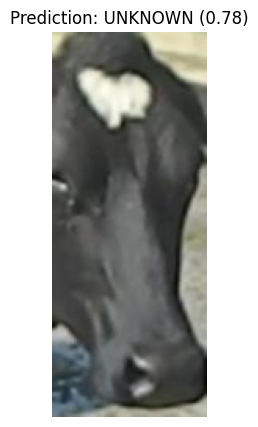

In [88]:
# Randomly select a cow ID from the dataset
example_cow = random.choice(list(cows.keys()))
# Randomly select an image belonging to that cow
query_path = random.choice(cows[example_cow])

# Print the path of the selected query image
print("Query image:", query_path)

# Run the identification function:
# - Loads the image
# - Generates its embedding
# - Compares it against all stored embeddings
# - Returns the predicted cow ID, similarity score, and ranked results
img, pred, score, results = identify_cow(query_path, mean_db)
# Display the predicted cow ID
print("\nPrediction:", pred)
# Display the similarity score rounded to four decimal places
print("Score:", round(score, 4))

# Print the top matches ranked by similarity
print("\nTop matches:")
for cow_id, sim in results:
    print(f"{cow_id}: {sim:.4f}")

show_image(img, f"Prediction: {pred} ({score:.2f})")

In [89]:
evaluate_model(cow_embeddings)

=== Evaluation Results ===
TP: 46
TN: 45
FP: 1
FN: 0
Accuracy: 0.9891


In [90]:
# Number of random test cases to run
num_tests = 10
# Loop through a set number of random tests
for _ in range(num_tests):
    # Randomly select a cow ID from the test set to ensure generalisation
    cow_id = random.choice(list(test_cows.keys()))
    # Randomly select one image belonging to that cow
    img_path = random.choice(test_cows[cow_id])

    # Run identification:
    # Generate embedding for the test image
    # Compare it against the database embeddings
    # Return predicted cow ID and similarity score
    img, pred, score, results = identify_cow(img_path, mean_db_generalisation)
    # Print the result:
    # True: actual cow ID
    # Pred: model's predicted cow ID
    # Score: similarity confidence
    print(f"True: {cow_id}, Pred: {pred}, Score: {round(score, 3)}")

True: s1877, Pred: s1877, Score: 0.966
True: s5562, Pred: s5562, Score: 0.962
True: s1877, Pred: s1877, Score: 0.94
True: s1906, Pred: s1906, Score: 0.947
True: s2011, Pred: s2011, Score: 0.901
True: s8819, Pred: s8819, Score: 0.893
True: sn23, Pred: sn23, Score: 0.825
True: sn22, Pred: sn22, Score: 0.844
True: s8835, Pred: s8835, Score: 0.894
True: s1797, Pred: s1797, Score: 0.908


In [91]:
# Get a list of all cow IDs from the embedding database
cow_ids = list(cow_embeddings.keys())
# Select two cows for comparison
cow1 = cow_ids[0]
cow2 = cow_ids[1]
# Compute similarity between two images of the same cow
same_sim = similarity(cow_embeddings[cow1][0], cow_embeddings[cow1][1])


# Compute similarity between images of two different cows
diff_sim = similarity(cow_embeddings[cow1][0], cow_embeddings[cow2][0])
# Print the similarity scores for comparison
print(f"Same-cow similarity ({cow1}): {same_sim:.4f}")
print(f"Different-cow similarity ({cow1} vs {cow2}): {diff_sim:.4f}")

Same-cow similarity (n2005): 0.9666
Different-cow similarity (n2005 vs s114): 0.5581


In [92]:
def show_side_by_side(path1, path2, title1="", title2=""):
    # Load and preprocess both images using the load_face function
    img1 = load_face(path1)
    img2 = load_face(path2)

    plt.figure(figsize=(10, 4))
# Display first image
    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(title1)
    plt.axis("off")
    # Display second image
    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(title2)
    plt.axis("off")

    plt.show()

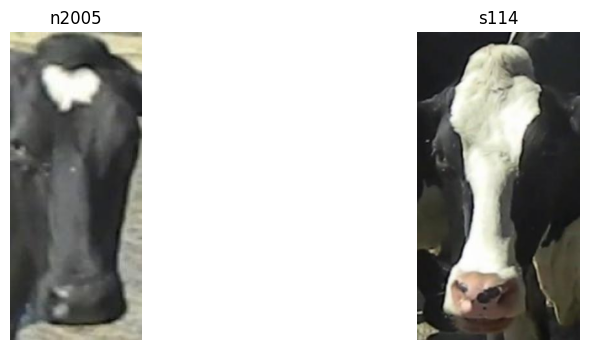

In [93]:
show_side_by_side(
    cows[cow1][0],
    cows[cow2][0],
    title1=cow1,
    title2=cow2
)

In [94]:
# Create a list to store information about each cow's embedding
embedding_rows = []
    # Loop through each cow ID and its corresponding embedding vector
for cow_id, embedding in mean_db.items():
    embedding_rows.append({
        "Cow ID": cow_id,
        "Embedding Shape": tuple(embedding.shape),
        "First 5 Values": embedding[:5].round(4)
    })
# Convert the list into a DataFrame
embedding_df = pd.DataFrame(embedding_rows)
embedding_df.head(10)

,Cow ID,Embedding Shape,First 5 Values
0,n2005,"(2048,)","[0.0004, 0.0096, 0.0015, 1e-04, 0.0012]"
1,s114,"(2048,)","[0.0005, 0.0061, 0.0006, 0.0002, 0.0012]"
2,s1547,"(2048,)","[0.0003, 0.0013, 1e-04, 0.0, 0.0005]"
3,s1556,"(2048,)","[1e-04, 0.0024, 0.0052, 0.0, 0.0011]"
4,s1557,"(2048,)","[0.0, 1e-04, 1e-04, 1e-04, 0.0]"
5,s1607,"(2048,)","[0.0006, 0.0006, 0.0003, 0.0, 0.0007]"
6,s1641,"(2048,)","[0.0008, 0.0052, 0.0011, 0.0, 0.0003]"
7,s1706,"(2048,)","[0.0004, 0.003, 0.0117, 0.0, 0.0002]"
8,s1774,"(2048,)","[0.002, 0.0002, 0.0003, 0.0, 0.0]"
9,s1778,"(2048,)","[0.0004, 0.0007, 0.0003, 1e-04, 1e-04]"


In [95]:
# Convert results into a DataFrame for analysis
results_df = pd.DataFrame(all_results)
results_df.head(20)

,True Cow ID,Predicted Cow ID,Similarity Score,Image Path
0,n2005,n2005,0.915881,Cattely-Augmented\n2005\726_rot.jpg
1,n2005,UNKNOWN,0.742384,Cattely-Augmented\n2005\3056_rot.jpg
2,n2005,n2005,0.895607,Cattely-Augmented\n2005\686_orig.jpg
3,n2005,n2005,0.846675,Cattely-Augmented\n2005\820_orig.jpg
4,n2005,n2005,0.893558,Cattely-Augmented\n2005\744_blur.jpg
5,n2005,UNKNOWN,0.659481,Cattely-Augmented\n2005\736_rot.jpg
6,n2005,n2005,0.925447,Cattely-Augmented\n2005\708_color.jpg
7,n2005,n2005,0.891813,Cattely-Augmented\n2005\826_orig.jpg
8,n2005,n2005,0.891295,Cattely-Augmented\n2005\832_orig.jpg
9,n2005,n2005,0.933765,Cattely-Augmented\n2005\694_color.jpg


In [96]:
same_scores = []
different_scores = []

cow_ids = list(test_cows.keys())

for cow_id in cow_ids:
    for test_img in test_cows[cow_id]:
        test_emb = get_embedding(load_face(test_img))

        # Compare test image to its own cow database embedding
        same_score = similarity(test_emb, mean_db_generalisation[cow_id])
        same_scores.append(same_score)

        # Compare test image to other cow database embeddings
        for other_cow_id in cow_ids:
            if other_cow_id != cow_id:
                diff_score = similarity(test_emb, mean_db_generalisation[other_cow_id])
                different_scores.append(diff_score)

print("Average same-cow similarity:", round(np.mean(same_scores), 4))
print("Average different-cow similarity:", round(np.mean(different_scores), 4))
print("Highest different-cow similarity:", round(np.max(different_scores), 4))
print("Lowest same-cow similarity:", round(np.min(same_scores), 4))

Average same-cow similarity: 0.9054
Average different-cow similarity: 0.5893
Highest different-cow similarity: 0.9319
Lowest same-cow similarity: 0.5328
